<div class="alert alert-block alert-info">
Singapore Management University<br>
CS105 Statistical Thinking for Data Science, 2025/26 Term 2
</div>

# CS105 Group Project Submission (Part I)

-----
Provide your team details, including section, team number, team members, and the name of the dataset. 
Complete all of the following sections. For any part requiring code to derive your answers, please create a code cell immediately below your response and run the code.
To edit any markdown cell, double click the cell; after editing, execute the markdown cell to collapse it.
<br>
-----

## Declaration

<span style="color:red">By submitting this notebook, we declare that **no part of this submission is generated by any AI tool**. We understand that AI-generated submissions will be considered as plagiarism, and just like other plagirisum cases, disciplinary actions will be imposed.</span>

#### Section: G5
#### Team: 67
#### Members:
1. CHIAM YI EN IRINA, 01536715
2. YEO KAI JIE JULIUS, 01490441
3. MING ZONG YOU MARTIN, 01469788
4. YAN HEIN LATT, 01524490
5. QUOID JING-XUAN ANDREL, 01533586

#### Dataset: [housing.csv](./data/housing.csv)

## Part I: Exploratory Data Analysis (EDA) [8% of final grade]

### 1. Overview of dataset [15% of Part I]

**a.** Summarise the background of the dataset [limited to 50 words]

This dataset contains census survey data regarding housing in a specific region. Each row represents a distinct town , detailing various environmental, structural, and socioeconomic attributes associated with it, along with the median price of homes

**b.** State the size of the dataset

The dataset consists of 506 rows and 14 columns.

**c.** For each variable, describe what it represents and its data type (numerical or categorical)

| Variable | Description | Data Type |
| --- | --- | --- |
| **ID** | Identification Number | Categorical |
| **Crime_Rate** | Crime rate per capita *("High" \| "Moderate" \| "Low")* | Categorical |
| **Residential_Area** | Percentage of residential area greater than 25,000 square feet *("Very High" \| "High" \| "Moderate" \| "Low" \| "Very Low")* | Categorical |
| **Non_Retail** | Percentage of business areas used for non-retail | Numerical |
| **River** | Near bridge *("Near" \| "Far")* | Categorical |
| **Pollutants** | Concentration of pollutants (parts per 10 million) | Numerical |
| **Rooms** | Number of rooms per unit | Numerical |
| **Old_Housing** | Percentage of units built before second world war | Numerical |
| **Distance_Office** | Weighted distances to major office areas | Numerical |
| **Highway_Access** | Accessibility to major highways *("High" \| "Moderate" \| "Low")*  | Categorical |
| **Tax_Rate** | Property tax rate per $10,000 | Numerical |
| **Student_Teacher_Ratio** | Student to teacher ratio | Numerical |
| **Low_Income** | Percentage of low income households | Numerical |
| **Price** | Median price of homes (in $1000s) | Numerical |

---

### 2. Data pre-processing [35% of Part I]

#### Imports and Load Data

In [201]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./data/housing.csv")

**a.** For each variable, determine the percentage of missing data. For any column with missing data, describe how you resolve the issue. Clearly state any assumption you made.

Missing data percentages were calculated by dividing the total null values by the length of the dataset.

We assume the missing values are missing at random.

To resolve this, missing categorical values were imputed using the mode (the most frequent category), and missing numerical values were imputed using the median, as the median is robust to potential outliers.

In [202]:
missing_pct = (df.isnull().sum() / len(df)) * 100
print("Percentage of missing data per variable:\n", missing_pct[missing_pct > 0])

categorical_cols = ["ID", "Crime_Rate", "Residential_Area", "River", "Highway_Access"]
numerical_cols = [
    "Non_Retail",
    "Pollutants",
    "Rooms",
    "Old_Housing",
    "Distance_Office",
    "Tax_Rate",
    "Student_Teacher_Ratio",
    "Low_Income",
    "Price",
]

# Impute categorical variables with MODE
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Impute numerical variables with MEDIAN
# We chose to impute missing values with the median because, as the exact midpoint of the sorted data, it is highly robust to outliers.

for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nTotal missing values after imputation:", df.isnull().sum().sum())

Percentage of missing data per variable:
 Crime_Rate    4.545455
Low_Income    4.347826
dtype: float64

Total missing values after imputation: 0


**b.** For each variable, identify outliers (if any) and describe how you resolve the issue. Clearly state any assumption you made.

We assume that values lying beyond 1.5 * IQR (Interquartile Range) are statistical outliers. But in a real estate context, these are valid extreme scenarios (e.g. luxury mansions or highly polluted areas) rather than errors.

Because we do not want to lose valuable data by dropping these rows, we resolved the issue by capping (Winsorizing) the outliers at the upper and lower bounds.

In [203]:
print("Number of outliers identified:")
for col in numerical_cols:
    df[col] = df[col].astype(float)

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)}")

    # capping values (winsorizing)
    df.loc[df[col] < lower_bound, col] = lower_bound
    df.loc[df[col] > upper_bound, col] = upper_bound

Number of outliers identified:
Non_Retail: 0
Pollutants: 0
Rooms: 30
Old_Housing: 0
Distance_Office: 5
Tax_Rate: 0
Student_Teacher_Ratio: 15
Low_Income: 11
Price: 40


**c.** For categorical variables, perform the necessary encoding.

First, the ID column was dropped because it acts only as an identifier and holds no predictive value. 

We then converted the remaining categorical data (Crime_Rate, Residential_Area, Highway_Access, River) into numerical values. Since these categories have a ranking (such as Low, Moderate, and High), we assigned them ordered numbers to preserve that ranking for the model.

In [204]:
# drop ID column as it serves no purpose in modeling
df = df.drop(columns=["ID"])

# enums for categorical variables
crime_map = {"Low": 0, "Moderate": 1, "High": 2}
res_map = {"Very Low": 0, "Low": 1, "Moderate": 2, "High": 3, "Very High": 4}
highway_map = {"Low": 0, "Moderate": 1, "High": 2}
river_map = {"Far": 0, "Near": 1}

# apply enums to categorical variables
df["Crime_Rate"] = df["Crime_Rate"].map(crime_map)
df["Residential_Area"] = df["Residential_Area"].map(res_map)
df["Highway_Access"] = df["Highway_Access"].map(highway_map)
df["River"] = df["River"].map(river_map)

# view updated dataframe
df.head()

,Crime_Rate,Residential_Area,Non_Retail,River,Pollutants,Rooms,Old_Housing,Distance_Office,Highway_Access,Tax_Rate,Student_Teacher_Ratio,Low_Income,Price
0,0,0,2.31,0,0.538,6.575,65.2,4.0900,0,296.0,15.3,4.98,24.0
1,0,0,7.07,0,0.469,6.421,78.9,4.9671,0,242.0,17.8,9.14,21.6
2,0,0,7.07,0,0.469,7.185,61.1,4.9671,0,242.0,17.8,4.03,34.7
3,0,0,2.18,0,0.458,6.998,45.8,6.0622,0,222.0,18.7,2.94,33.4
4,0,0,2.18,0,0.458,7.147,54.2,6.0622,0,222.0,18.7,5.33,36.2


### 3.	Exploratory analysis and visualization [50% of Part I]

**a.** For each variable, provide relevant summary statistics

Using the .describe() function, we generated summary statistics for all variables, which compute the central tendency (mean), dispersion (standard deviation), minimum, maximum, and the respective quartiles for the dataset.

In [205]:
df.describe().round(2)

,Crime_Rate,Residential_Area,Non_Retail,River,Pollutants,Rooms,Old_Housing,Distance_Office,Highway_Access,Tax_Rate,Student_Teacher_Ratio,Low_Income,Price
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,0.26,0.49,11.14,0.07,0.55,6.28,69.11,3.78,1.10,408.27,18.46,12.51,21.88
std,0.51,1.06,6.86,0.25,0.12,0.63,28.34,2.07,0.64,168.50,2.14,6.77,7.60
min,0.00,0.00,0.46,0.00,0.38,4.78,2.90,1.13,0.00,187.00,13.20,1.73,5.06
25%,0.00,0.00,5.19,0.00,0.45,5.89,45.18,2.10,1.00,279.25,17.40,7.20,17.02
50%,0.00,0.00,9.69,0.00,0.54,6.21,78.20,3.21,1.00,330.00,19.05,11.36,21.20
75%,0.00,0.00,18.10,0.00,0.62,6.62,94.57,5.19,2.00,666.00,20.20,16.49,25.00
max,2.00,4.00,27.74,1.00,0.87,7.73,102.00,9.82,2.00,711.00,22.00,30.42,36.96


**b.** For each variable, provide an appropriate visualisation depicting the distribution of its values, and summarize any key observation(s) you made.

We will use Histograms to visualise continuous numerical variables, while count plots will be used for discrete/categorical variables.

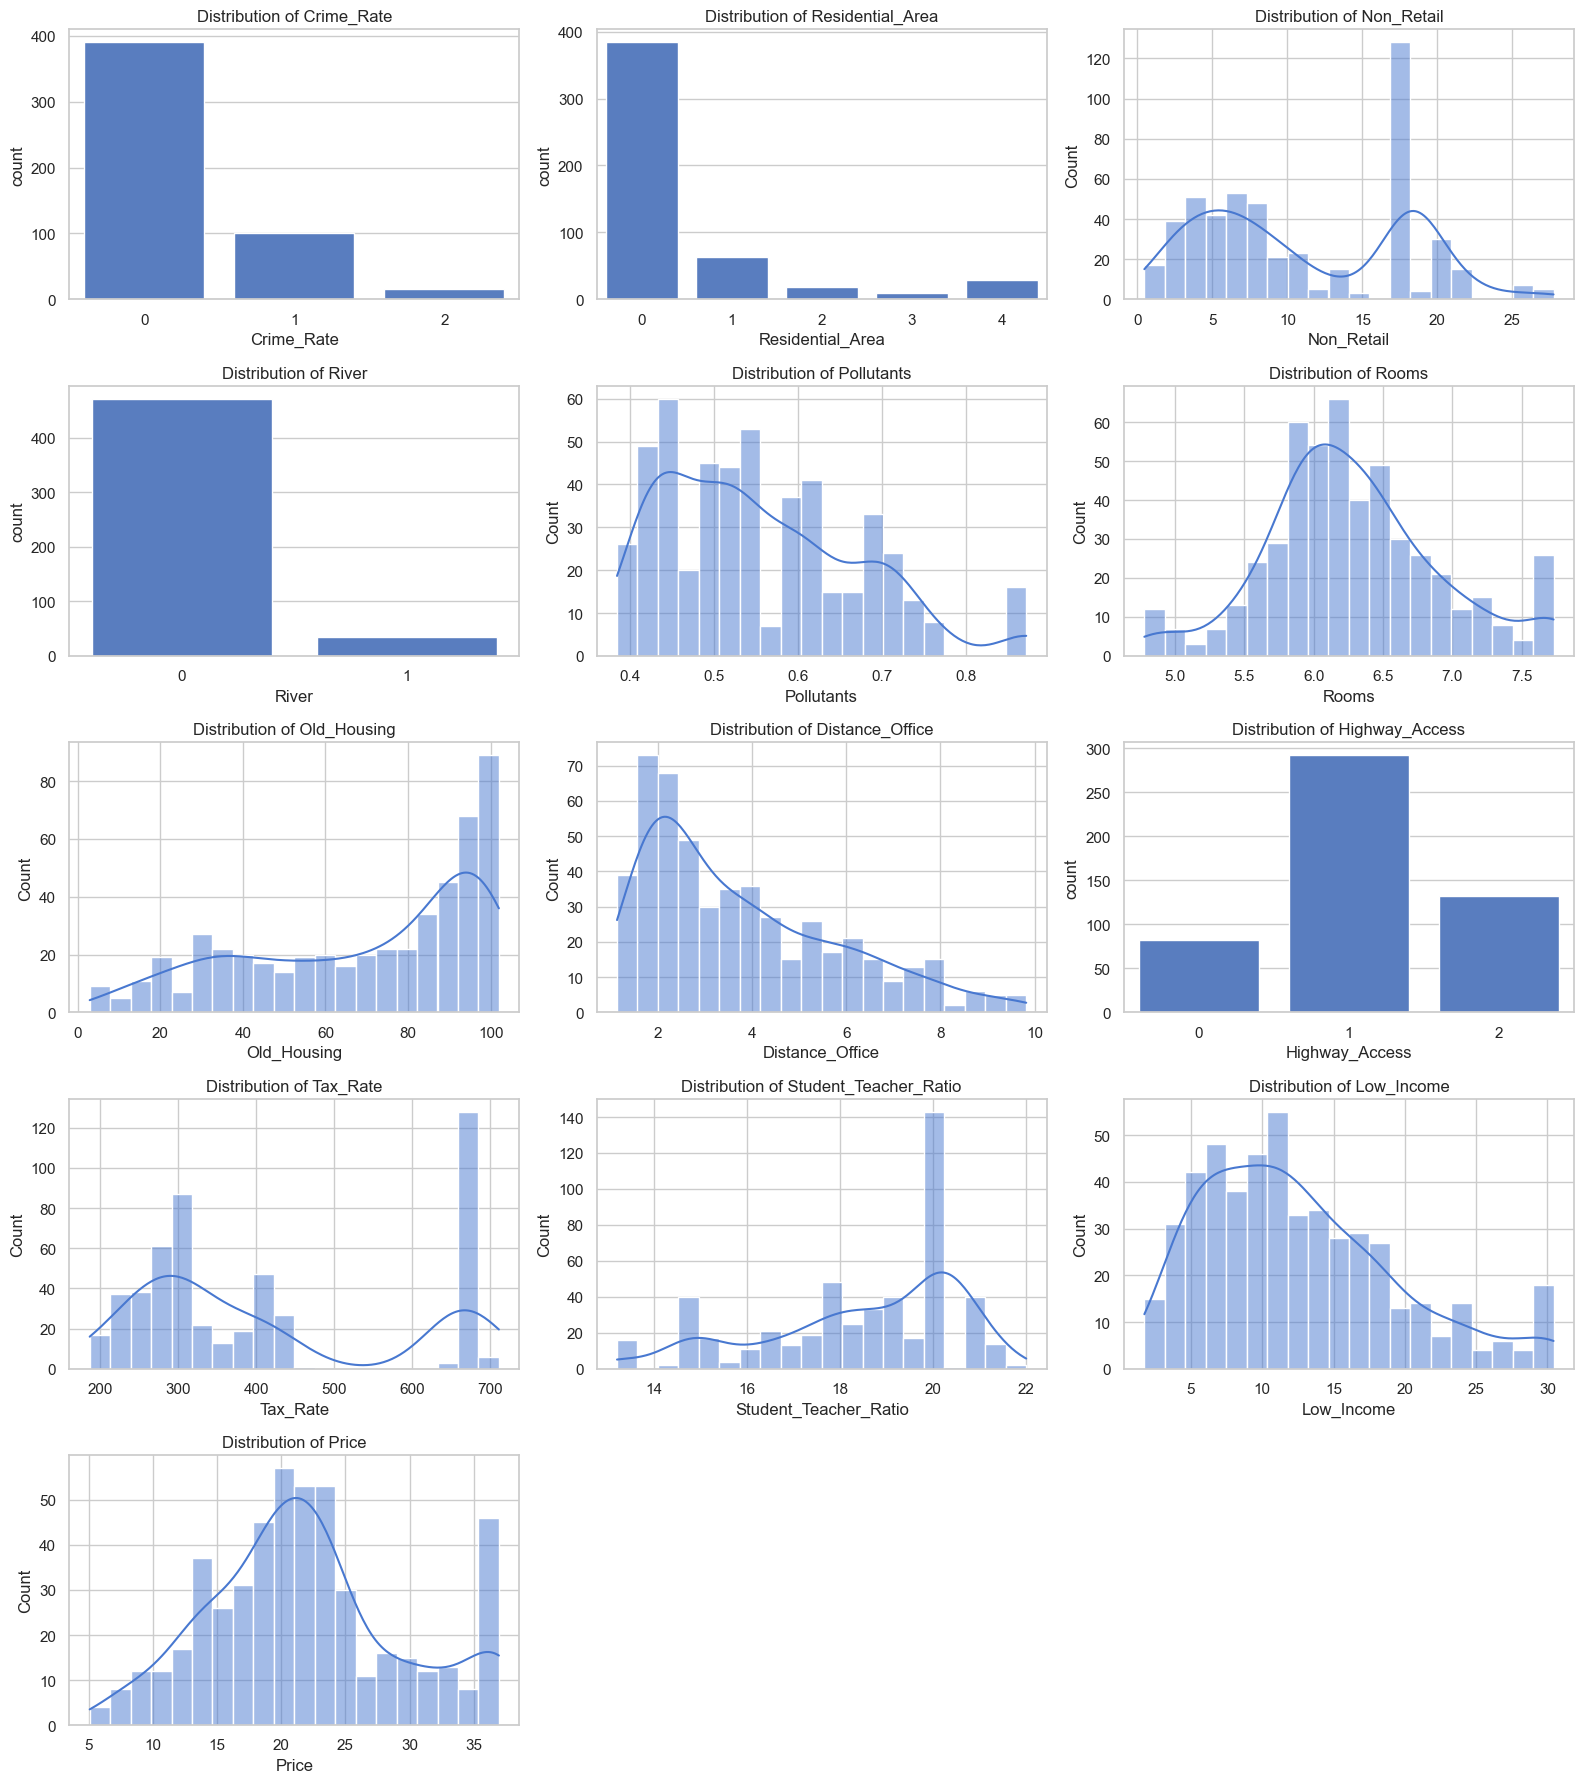

In [206]:
sns.set_theme(style="whitegrid", palette=sns.color_palette("muted"))
plt.figure(figsize=(16, 18))

for i, col in enumerate(df.columns, 1):
    plt.subplot(5, 3, i)
    if df[col].nunique() > 5:
        sns.histplot(df[col], kde=True, bins=20)
    else:
        sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.tight_layout()

plt.show()

### Categorical Distributions

1. **Crime Rate:** Most neighborhoods have low crime (0), with very few falling into the moderate (1) or high (2) categories.
2. **Residential Area:** Almost all properties are in the "Very Low" (0) zone. There are barely in the higher categories.
3. **River:** This one is pretty one-sided. Nearly every property is far from the river (0), with almost none right next to it (1).
4. **Highway Access:** Most places have moderate (1) highway access. High access (2) is also pretty common, but low access (0) is rare.

### Bimodal Distributions

1. **Tax Rate:** The data splits into two separate groups here, one group is in a lower tax bracket (around 200–350) and the other group is hit with a much higher tax rate (around 650–700).
2. **Non Retail:** We see two separate grounds again, one around 5 and the other around 18. This basically means we have two completely different types of neighborhoods when it comes to the amount of non-retail businesses.

### Skewed Distributions

**Right-Skewed:** 
1. **Distance Office:** Most homes are fairly close to work centers (scoring 1–4), and the numbers just get lower the further away you go.
2. **Low Income:** Most areas have a lower percentage of low-income residents (around 5–15%), and it steadily drops off as the percentages go up.
3. **Pollutants:** Pollution levels mostly hover on the lower end (0.4–0.6) and fade out as the levels get higher.

**Left-Skewed:**

1. **Old Housing:** A lot of the houses here are very old. There’s a huge spike right at the top end of the scale (near 100).
2. **Student Teacher Ratio:** Class sizes tend to be on the larger side, with a really big jump right around 20 to 21 students per teacher.

### Normal Distributions

1. **Rooms:** This looks like a classic bell curve. Most homes have around 6 to 6.5 rooms, with fewer homes having a lot more or a lot less.
2. **Price:** Prices generally form a bell curve peaking in the low 20s. 

### C. Perform bi-variate analysis on the variables. You do not need to present the analysis of every pair of variables; only focus on the pairs you believe are worth investigating and explain. For each pair, describe the relationship between the two variables. Use appropriate statistical methods and/or visualizations.

#### Global Relationships between All Variables

We generated a correlation heatmap to understand the global relationships between all variables.

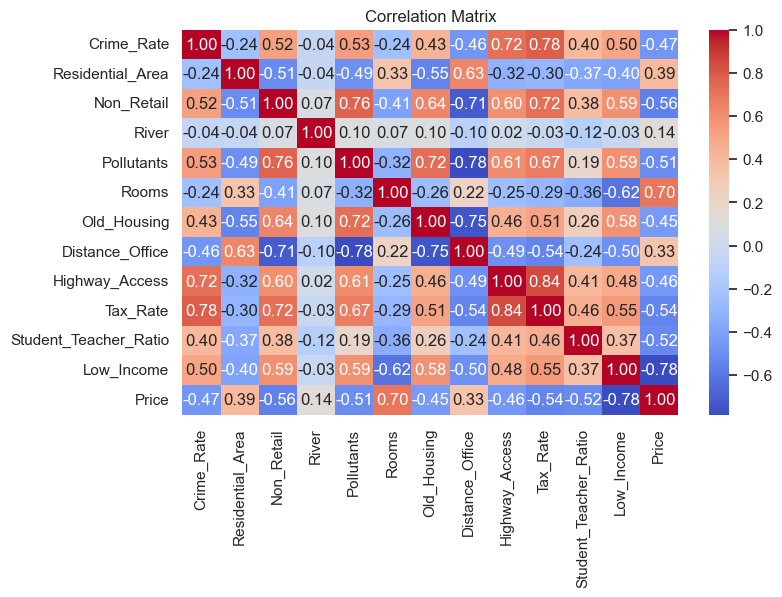

In [207]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

For our targeted bi-variate analysis, we utilised the correlation coefficient from our heatmap to identify pairs with strong linear relationships. 

We chose to investigate the pairs (Rooms per unit vs Price) and (Low Income vs Price) because physical space and socioeconomic status are typically strong logical drivers of real estate value. Furthermore, to understand interactions between the neighborhood features themselves, we investigated (Distance to Office vs Pollutants) to analyse the environmental impact of proximity to business centers, and (Highway Access vs Tax Rate) to examine how public infrastructure influences local property tax brackets.



#### Rooms per unit vs Price

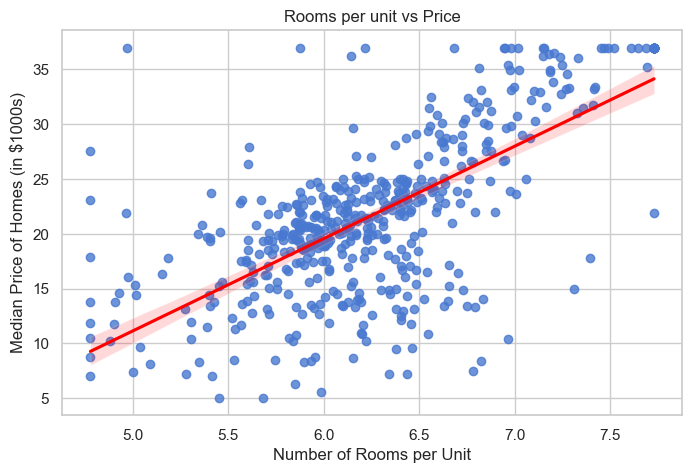

In [208]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="Rooms", y="Price", line_kws={"color": "red"})
plt.title("Rooms per unit vs Price")
plt.xlabel("Number of Rooms per Unit")
plt.ylabel("Median Price of Homes (in $1000s)")
plt.show()


The scatterplot reveals a strong positive linear relationship (r = 0.70). As the number of rooms increases, the median price naturally rises.

#### Low Income Household % vs Price

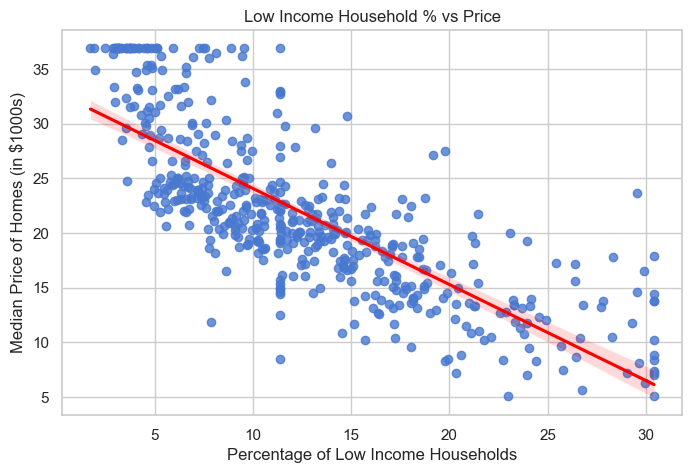

In [209]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="Low_Income", y="Price", line_kws={"color": "red"})
plt.title("Low Income Household % vs Price")
plt.xlabel("Percentage of Low Income Households")
plt.ylabel("Median Price of Homes (in $1000s)")
plt.show()

The scatterplot demonstrates a clear negative relationship (r = -0.78). Neighborhoods with a higher percentage of low-income households correspond strongly to lower median home prices.

#### Distance to Office vs Pollutants 

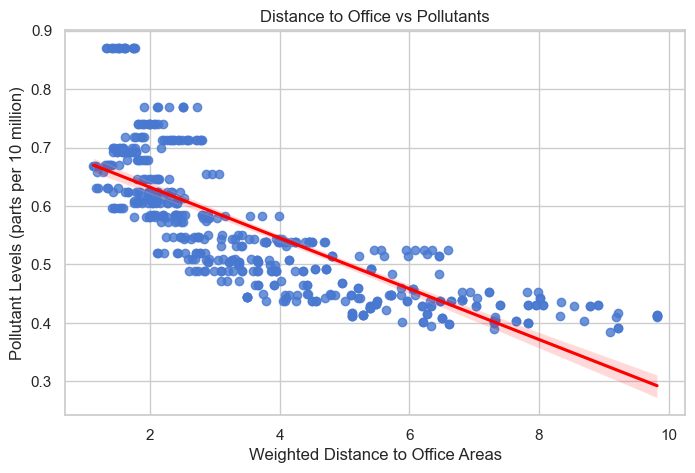

In [210]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="Distance_Office", y="Pollutants", line_kws={"color": "red"})
plt.title("Distance to Office vs Pollutants")
plt.xlabel("Weighted Distance to Office Areas")
plt.ylabel("Pollutant Levels (parts per 10 million)")
plt.show()

Using a scatter plot, we observe a strong negative correlation (r = -0.78). Homes located further away from major office and business areas experience significantly lower pollutant levels, indicating that employment centers are the primary source of emissions.

#### Highway Access vs Tax Rate

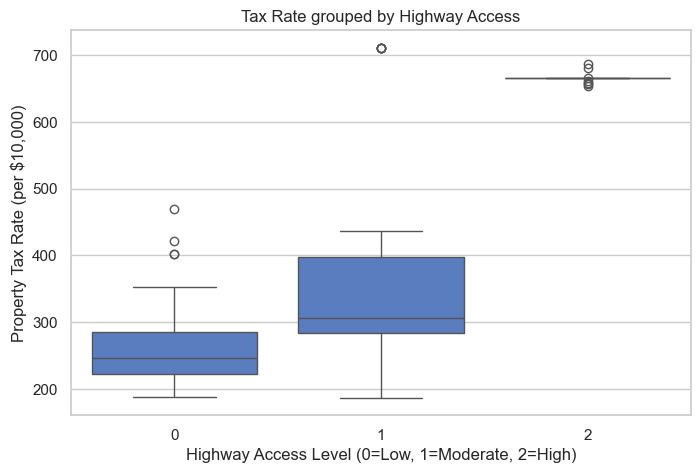

In [211]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Highway_Access', y='Tax_Rate')
plt.title("Tax Rate grouped by Highway Access")
plt.xlabel("Highway Access Level (0=Low, 1=Moderate, 2=High)")
plt.ylabel("Property Tax Rate (per $10,000)")
plt.show()

Because Highway Access is a categorical variable, we utilised a grouped boxplot for this bi-variate analysis (r = 0.84). The boxplot reveals a massive disparity, neighborhoods with "High" highway access are subjected to significantly higher and tightly clustered property tax rates compared to those with "Low" or "Moderate" access.